In [39]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [40]:
df = pd.read_csv("HateSpeechDataset.csv")

df = df[['Content', 'Label']]
df.rename(columns={'Content': 'text', 'Label': 'label'}, inplace=True)

# 🔥 FIX DATASET ISSUE
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df.dropna(inplace=True)
df['label'] = df['label'].astype(int)

df.reset_index(drop=True, inplace=True)

print(df.head())
print(df['label'].value_counts())

                                                text  label
0  denial of normal the con be asked to comment o...      1
1  just by being able to tweet this insufferable ...      1
2  that is retarded you too cute to be single tha...      1
3  thought of a real badass mongol style declarat...      1
4                                afro american basho      1
label
0    361594
1     79305
Name: count, dtype: int64


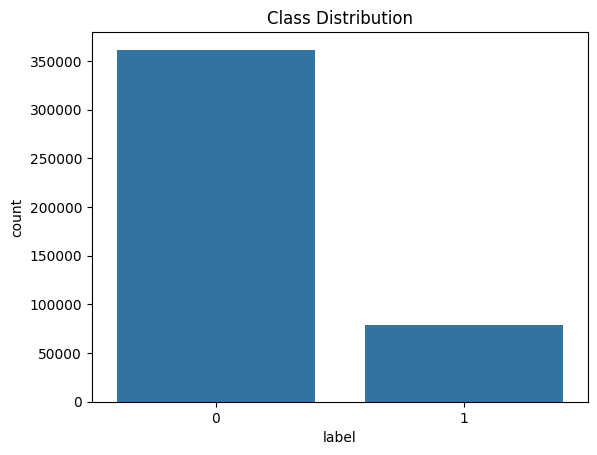

In [22]:
sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.show()

In [41]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@[\w]*', '', text)
    text = re.sub(r'#', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]

    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,clean_text
0,denial of normal the con be asked to comment o...,denial normal con asked comment tragedies emot...
1,just by being able to tweet this insufferable ...,able tweet insufferable bullshit proves trump ...
2,that is retarded you too cute to be single tha...,retarded cute single life
3,thought of a real badass mongol style declarat...,thought real badass mongol style declaration w...
4,afro american basho,afro american basho


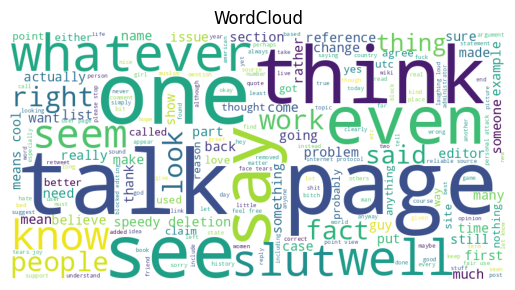

In [42]:
from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis('off')
plt.title("WordCloud")
plt.show()

In [43]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

X = tfidf.fit_transform(df['clean_text'])
y = df['label']

In [44]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Linear SVM": LinearSVC(class_weight='balanced'),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=50,
    max_depth=20,
    n_jobs=-1 )
}

In [51]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    results.append([name, acc, f1])

    print(name)
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("-"*30)

Logistic Regression
Accuracy: 0.8199364935359492
F1 Score: 0.6150974498206148
------------------------------
Linear SVM
Accuracy: 0.8167384894533908
F1 Score: 0.6098691516585389
------------------------------
Naive Bayes
Accuracy: 0.8563393059650715
F1 Score: 0.5430344131015078
------------------------------
Random Forest
Accuracy: 0.8211839419369471
F1 Score: 0.008925204274041483
------------------------------


In [52]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
print(results_df)

                 Model  Accuracy  F1 Score
0  Logistic Regression  0.819936  0.615097
1           Linear SVM  0.816738  0.609869
2          Naive Bayes  0.856339  0.543034
3        Random Forest  0.821184  0.008925


In [58]:
best_model = LogisticRegression(class_weight='balanced')
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_val)

In [54]:
print("Accuracy:", accuracy_score(y_val, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))

Accuracy: 0.8199364935359492

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.82      0.88     72346
           1       0.50      0.80      0.62     15834

    accuracy                           0.82     88180
   macro avg       0.72      0.81      0.75     88180
weighted avg       0.87      0.82      0.83     88180



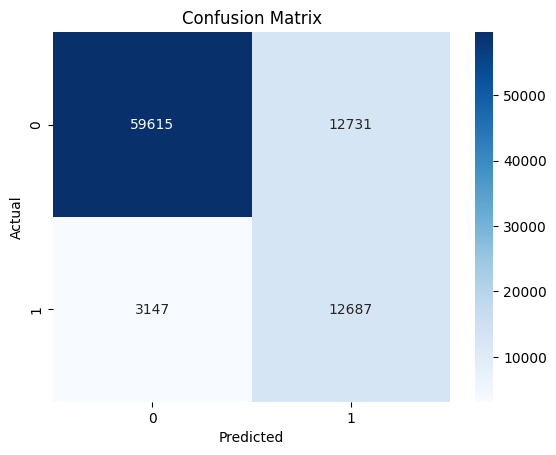

In [55]:
cm = confusion_matrix(y_val, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [56]:
test_samples = [
    "you are stupid",
    "i love this product",
    "go kill yourself",
    "have a nice day"
]

for text in test_samples:
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])
    pred = best_model.predict(vector)[0]

    print(text, "→", "Toxic" if pred==1 else "Non-Toxic")

you are stupid → Toxic
i love this product → Non-Toxic
go kill yourself → Toxic
have a nice day → Non-Toxic


In [57]:
import pickle

pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))